 ## 1. Setup and Data Loading


In [54]:
# ============================================
# 1.1 Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
%matplotlib inline
#plt.style.use('seaborn-v0-8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Libraries imported successfully!
Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


In [55]:
# ============================================
# 1.2 Load Data
# ============================================
# Load the clean dataset
df = pd.read_csv("/content/mexico-real-estate-combined-clean.csv")

# Quick data overview
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATASET OVERVIEW ===
Shape: (1736, 6)

Columns: ['property_type', 'state', 'lat', 'lon', 'area_m2', 'price_usd']

First 5 rows:
  property_type             state   lat     lon  area_m2  price_usd
0         house  Estado de México 19.56  -99.23   150.00   67965.56
1         house        Nuevo León 25.69 -100.20   186.00   63223.78
2     apartment          Guerrero 16.77  -99.76    82.00   84298.37
3     apartment          Guerrero 16.83  -99.91   150.00   94308.80
4         house           Yucatán 21.05  -89.54   205.00  105191.37

=== DATA TYPES ===
property_type     object
state             object
lat              float64
lon              float64
area_m2          float64
price_usd        float64
dtype: object

=== MISSING VALUES ===
property_type    0
state            0
lat              0
lon              0
area_m2          0
price_usd        0
dtype: int64


#2. Exploratory Data Analysis

In [56]:
# ============================================
# 2.1 Descriptive Statistics
# ============================================
print("=== DESCRIPTIVE STATISTICS ===")
print(df[['price_usd', 'area_m2']].describe())

=== DESCRIPTIVE STATISTICS ===
       price_usd  area_m2
count    1736.00  1736.00
mean   115331.98   170.26
std     65426.17    80.59
min     33157.89    60.00
25%     65789.47   101.75
50%     99262.13   156.00
75%    150846.66   220.00
max    326733.66   385.00


In [57]:
# ============================================
# 2.2 Feature Engineering - Price per m²
# ============================================
df = df.assign(price_per_m2 = lambda x: x['price_usd'] / x['area_m2'])

print("=== PRICE PER M² STATISTICS ===")
print(df['price_per_m2'].describe())

print("\n=== SAMPLE DATA ===")
print(df[['area_m2', 'price_usd', 'price_per_m2']].head())

=== PRICE PER M² STATISTICS ===
count   1736.00
mean     733.45
std      429.35
min      120.30
25%      489.32
50%      614.04
75%      806.42
max     3700.66
Name: price_per_m2, dtype: float64

=== SAMPLE DATA ===
   area_m2  price_usd  price_per_m2
0   150.00   67965.56        453.10
1   186.00   63223.78        339.91
2    82.00   84298.37       1028.03
3   150.00   94308.80        628.73
4   205.00  105191.37        513.13


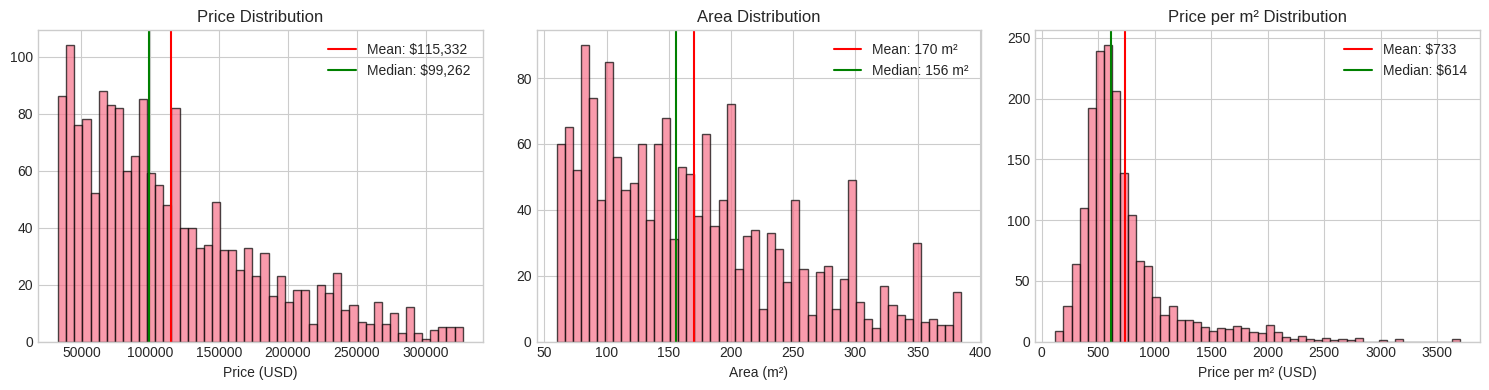

In [58]:
# ============================================
# 2.3 Distribution Analysis
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Price distribution
axes[0].hist(df['price_usd'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['price_usd'].mean(), color='red', label=f'Mean: ${df["price_usd"].mean():,.0f}')
axes[0].axvline(df['price_usd'].median(), color='green', label=f'Median: ${df["price_usd"].median():,.0f}')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (USD)')
axes[0].legend()

# Area distribution
axes[1].hist(df['area_m2'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(df['area_m2'].mean(), color='red', label=f'Mean: {df["area_m2"].mean():.0f} m²')
axes[1].axvline(df['area_m2'].median(), color='green', label=f'Median: {df["area_m2"].median():.0f} m²')
axes[1].set_title('Area Distribution')
axes[1].set_xlabel('Area (m²)')
axes[1].legend()

# Price per m² distribution
axes[2].hist(df['price_per_m2'], bins=50, edgecolor='black', alpha=0.7)
axes[2].axvline(df['price_per_m2'].mean(), color='red', label=f'Mean: ${df["price_per_m2"].mean():.0f}')
axes[2].axvline(df['price_per_m2'].median(), color='green', label=f'Median: ${df["price_per_m2"].median():.0f}')
axes[2].set_title('Price per m² Distribution')
axes[2].set_xlabel('Price per m² (USD)')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Correlation Analysis

In [59]:
# ============================================
# 3.1 Correlation Between Area and Price
# ============================================
corr_price_area = df['area_m2'].corr(df['price_usd'])
print("=== CORRELATION ANALYSIS ===")
print(f"Correlation between area and price: {corr_price_area:.4f}")
print(f"R-squared: {corr_price_area**2:.4f} ({corr_price_area**2*100:.1f}% of price explained by area)")

# Interpretation
if corr_price_area > 0.7:
    print("Strong positive relationship")
elif corr_price_area > 0.4:
    print("Moderate positive relationship")
elif corr_price_area > 0.1:
    print("Weak positive relationship")
else:
    print("Weak or no relationship")

=== CORRELATION ANALYSIS ===
Correlation between area and price: 0.5855
R-squared: 0.3428 (34.3% of price explained by area)
Moderate positive relationship



=== CORRELATION MATRIX ===
               lat   lon  area_m2  price_usd  price_per_m2
lat           1.00 -0.48     0.08      -0.09         -0.17
lon          -0.48  1.00     0.10       0.03         -0.03
area_m2       0.08  0.10     1.00       0.59         -0.28
price_usd    -0.09  0.03     0.59       1.00          0.54
price_per_m2 -0.17 -0.03    -0.28       0.54          1.00


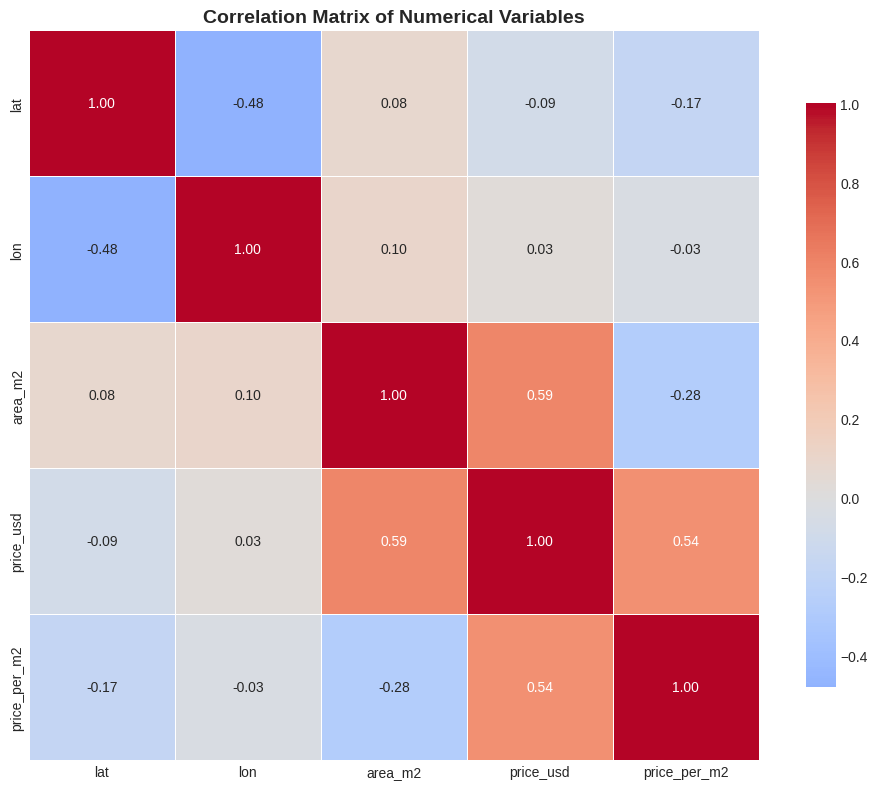

In [60]:
# ============================================
# 3.2 Correlation Matrix
# ============================================
# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

print("\n=== CORRELATION MATRIX ===")
print(corr_matrix.round(4))

# Heatmap visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

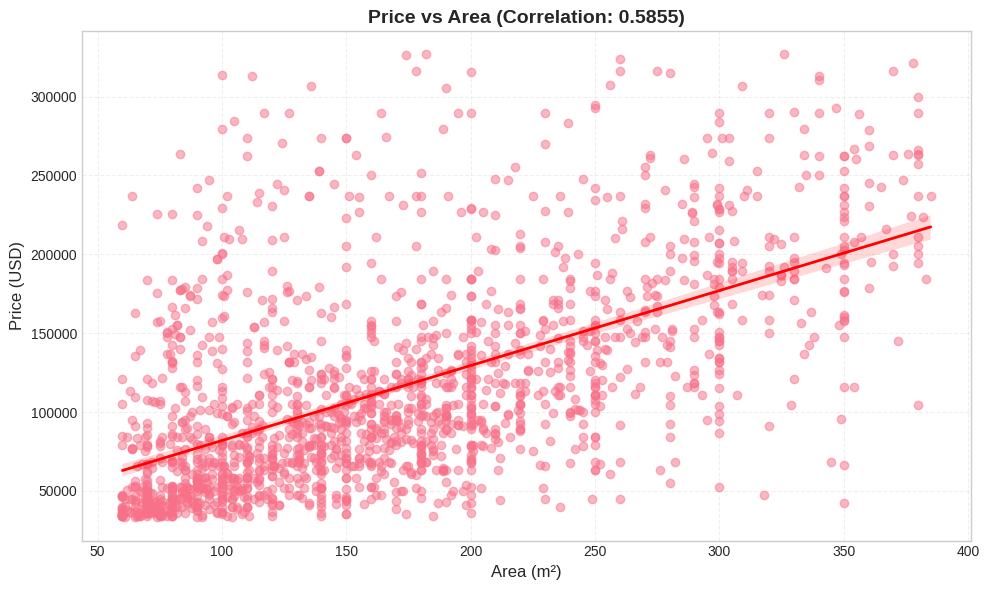

In [61]:
# ============================================
# 3.3 Scatter Plot with Regression Line
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df,
    x='area_m2',
    y='price_usd',
    ax=ax,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'linewidth': 2}
)

ax.set_title(f'Price vs Area (Correlation: {corr_price_area:.4f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Area (m²)', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#4. State-Level Analysis

In [62]:
# ============================================
# 4.1 Price per m² by State
# ============================================
state_price_stats = (
    df
    .groupby('state')
    ['price_per_m2']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('median', ascending=False)
)

print("=== PRICE PER M² BY STATE ===")
print(state_price_stats)

print("\n=== TOP 5 MOST EXPENSIVE STATES ===")
print(state_price_stats.head(5))

print("\n=== BOTTOM 5 LEAST EXPENSIVE STATES ===")
print(state_price_stats.tail(5))

=== PRICE PER M² BY STATE ===
                                   mean  median    std  count
state                                                        
Distrito Federal                1175.89  958.89 651.13    303
Guerrero                         761.56  715.03 270.52     49
Quintana Roo                     736.46  707.91 265.71     38
Oaxaca                           683.02  683.02 196.87      2
Estado de México                 763.75  674.30 396.69    179
Campeche                         601.29  654.74 157.02      3
Nayarit                          599.29  651.38 196.19      9
Querétaro                        687.23  644.17 230.29    128
Jalisco                          743.57  641.55 370.42     60
Baja California Sur              662.40  625.00 210.34     15
Puebla                           700.70  622.41 274.10     95
Morelos                          649.38  620.61 186.92    160
Guanajuato                       672.91  600.11 260.79     12
Chihuahua                        591.23 

In [63]:
# ============================================
# 4.1 Price per m² by State
# ============================================
state_price_stats = (
    df
    .groupby('state')
    ['price_per_m2']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('median', ascending=False)
)

print("=== PRICE PER M² BY STATE ===")
print(state_price_stats)

print("\n=== TOP 5 MOST EXPENSIVE STATES ===")
print(state_price_stats.head(5))

print("\n=== BOTTOM 5 LEAST EXPENSIVE STATES ===")
print(state_price_stats.tail(5))

=== PRICE PER M² BY STATE ===
                                   mean  median    std  count
state                                                        
Distrito Federal                1175.89  958.89 651.13    303
Guerrero                         761.56  715.03 270.52     49
Quintana Roo                     736.46  707.91 265.71     38
Oaxaca                           683.02  683.02 196.87      2
Estado de México                 763.75  674.30 396.69    179
Campeche                         601.29  654.74 157.02      3
Nayarit                          599.29  651.38 196.19      9
Querétaro                        687.23  644.17 230.29    128
Jalisco                          743.57  641.55 370.42     60
Baja California Sur              662.40  625.00 210.34     15
Puebla                           700.70  622.41 274.10     95
Morelos                          649.38  620.61 186.92    160
Guanajuato                       672.91  600.11 260.79     12
Chihuahua                        591.23 

In [64]:
# ============================================
# 4.2 Variance Decomposition
# ============================================
total_variance = df['price_usd'].var()
state_means = df.groupby('state')['price_usd'].mean()
between_variance = state_means.var()
within_variance = df.groupby('state')['price_usd'].var().mean()

between_pct = (between_variance / total_variance) * 100
within_pct = (within_variance / total_variance) * 100

print("=== VARIANCE DECOMPOSITION ===")
print(f"Total variance: ${total_variance:,.0f}")
print(f"Between-state variance: ${between_variance:,.0f}")
print(f"Within-state variance: ${within_variance:,.0f}")
print(f"\nBetween-state variance: {between_pct:.1f}%")
print(f"Within-state variance: {within_pct:.1f}%")
print(f"Ratio (Between/Within): {between_variance/within_variance:.2f}")

if between_pct > 50:
    print("\n Location (state) explains most of the price variation")
else:
    print(f"\n Location explains {between_pct:.1f}% of price variation")

=== VARIANCE DECOMPOSITION ===
Total variance: $4,280,584,217
Between-state variance: $506,384,115
Within-state variance: $3,350,525,413

Between-state variance: 11.8%
Within-state variance: 78.3%
Ratio (Between/Within): 0.15

 Location explains 11.8% of price variation


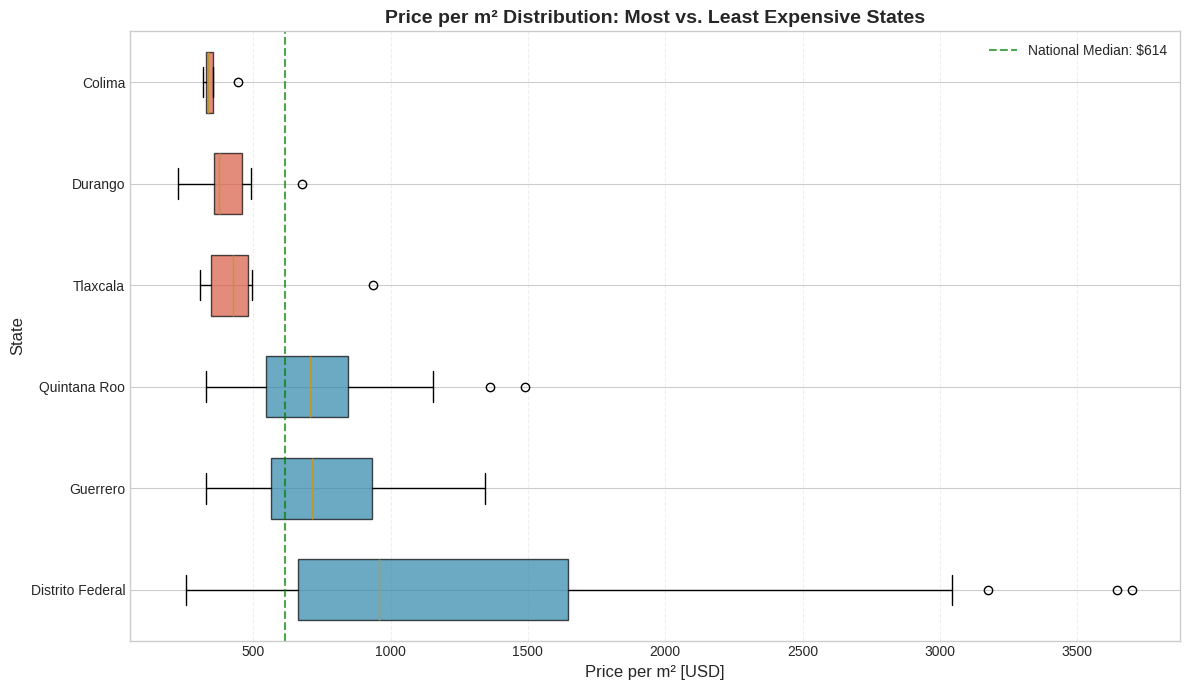

In [65]:
# ============================================
# 4.3 Top 3 vs Bottom 3 States Boxplot
# ============================================
top_states = state_price_stats.head(3).index.tolist()
bottom_states = state_price_stats.tail(3).index.tolist()
target_states = top_states + bottom_states

df_states = df[df['state'].isin(target_states)]
data_to_plot = [df_states[df_states['state'] == s]['price_per_m2'] for s in target_states]

fig, ax = plt.subplots(figsize=(12, 7))

box = ax.boxplot(
    data_to_plot,
    tick_labels=target_states,
    vert=False,
    patch_artist=True,
    widths=0.6
)

# Color coding: blue for top states, red for bottom states
colors = ['#2E86AB'] * 3 + ['#D95B43'] * 3
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Price per m² Distribution: Most vs. Least Expensive States', fontsize=14, fontweight='bold')
ax.set_xlabel('Price per m² [USD]', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add overall median line
overall_median = df['price_per_m2'].median()
ax.axvline(x=overall_median, color='green', linestyle='--', alpha=0.7,
           label=f'National Median: ${overall_median:,.0f}')
ax.legend()

plt.tight_layout()
plt.show()

#5. Property Type Analysis

In [66]:
# ============================================
# 5.1 Price per m² by Property Type
# ============================================
property_type_stats = (
    df
    .groupby('property_type')
    ['price_per_m2']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('median', ascending=False)
)

print("=== PRICE PER M² BY PROPERTY TYPE ===")
print(property_type_stats)

most_expensive = property_type_stats.index[0]
cheapest = property_type_stats.index[-1]
print(f"\nMost expensive: {most_expensive} (${property_type_stats.iloc[0]['median']:.2f}/m²)")
print(f"Least expensive: {cheapest} (${property_type_stats.iloc[-1]['median']:.2f}/m²)")

=== PRICE PER M² BY PROPERTY TYPE ===
                 mean  median    std  count
property_type                              
apartment     1138.51  958.89 600.82    407
house          609.40  570.77 254.55   1329

Most expensive: apartment ($958.89/m²)
Least expensive: house ($570.77/m²)


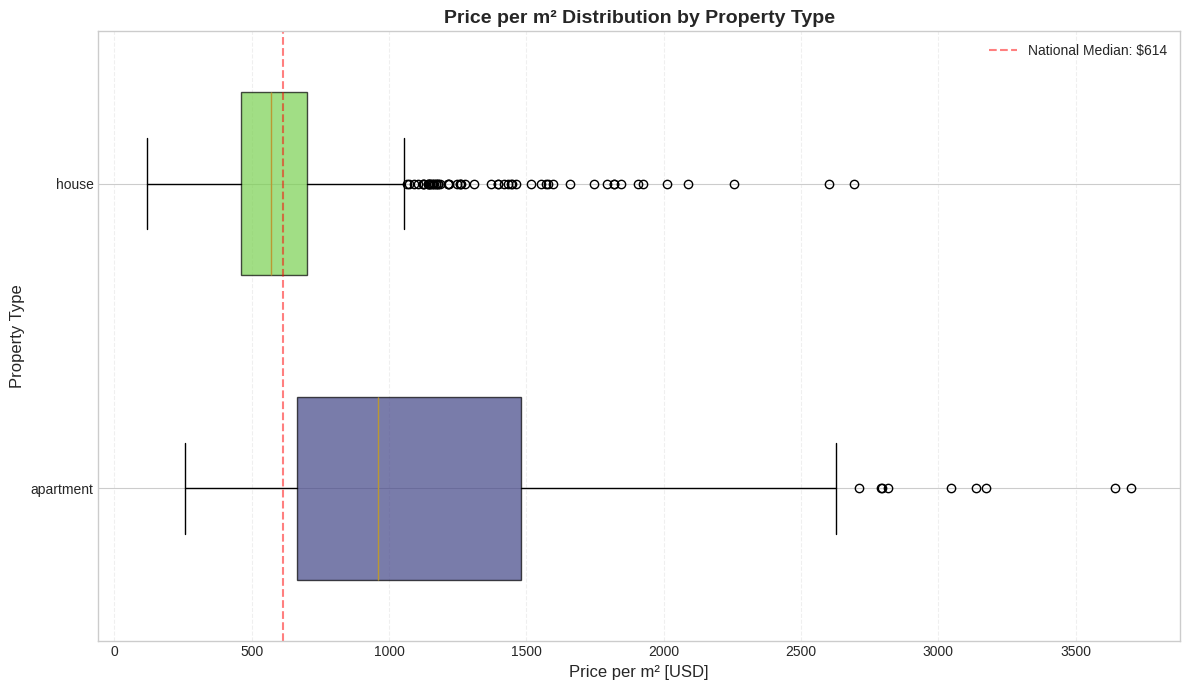

In [67]:
# ============================================
# 5.2 Property Type Boxplot
# ============================================
prop_types = property_type_stats.index.tolist()
data_by_type = [df[df['property_type'] == p]['price_per_m2'] for p in prop_types]

fig, ax = plt.subplots(figsize=(12, 7))

box = ax.boxplot(
    data_by_type,
    tick_labels=prop_types,
    vert=False,
    patch_artist=True,
    widths=0.6
)

# Color each box differently
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(prop_types)))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Price per m² Distribution by Property Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Price per m² [USD]', fontsize=12)
ax.set_ylabel('Property Type', fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add overall median line
ax.axvline(x=overall_median, color='red', linestyle='--', alpha=0.5,
           label=f'National Median: ${overall_median:,.0f}')
ax.legend()

plt.tight_layout()
plt.show()

#6. Combined Analysis

In [68]:
# ============================================
# 6.1 State × Property Type Combinations
# ============================================
combined_stats = (
    df
    .groupby(['state', 'property_type'])
    ['price_per_m2']
    .agg(['median', 'count'])
    .round(2)
)

# Filter for groups with at least 5 properties
combined_stats = combined_stats[combined_stats['count'] >= 5]
combined_stats = combined_stats.sort_values('median', ascending=False)

print("=== TOP 15 STATE-PROPERTY TYPE COMBINATIONS ===")
print(combined_stats.head(15))

print("\n=== BOTTOM 10 STATE-PROPERTY TYPE COMBINATIONS ===")
print(combined_stats.tail(10))

=== TOP 15 STATE-PROPERTY TYPE COMBINATIONS ===
                                               median  count
state                           property_type               
Nuevo León                      apartment     1424.90     12
Jalisco                         apartment     1288.66      8
Distrito Federal                apartment     1140.09    214
Quintana Roo                    apartment     1003.79     11
Querétaro                       apartment     1003.41     12
Estado de México                apartment      969.18     27
Puebla                          apartment      960.88     22
Veracruz de Ignacio de la Llave apartment      818.62     10
Yucatán                         apartment      799.68     21
Guerrero                        apartment      778.35     27
Distrito Federal                house          711.24     89
Guerrero                        house          695.47     22
Morelos                         apartment      661.35     12
Estado de México                house

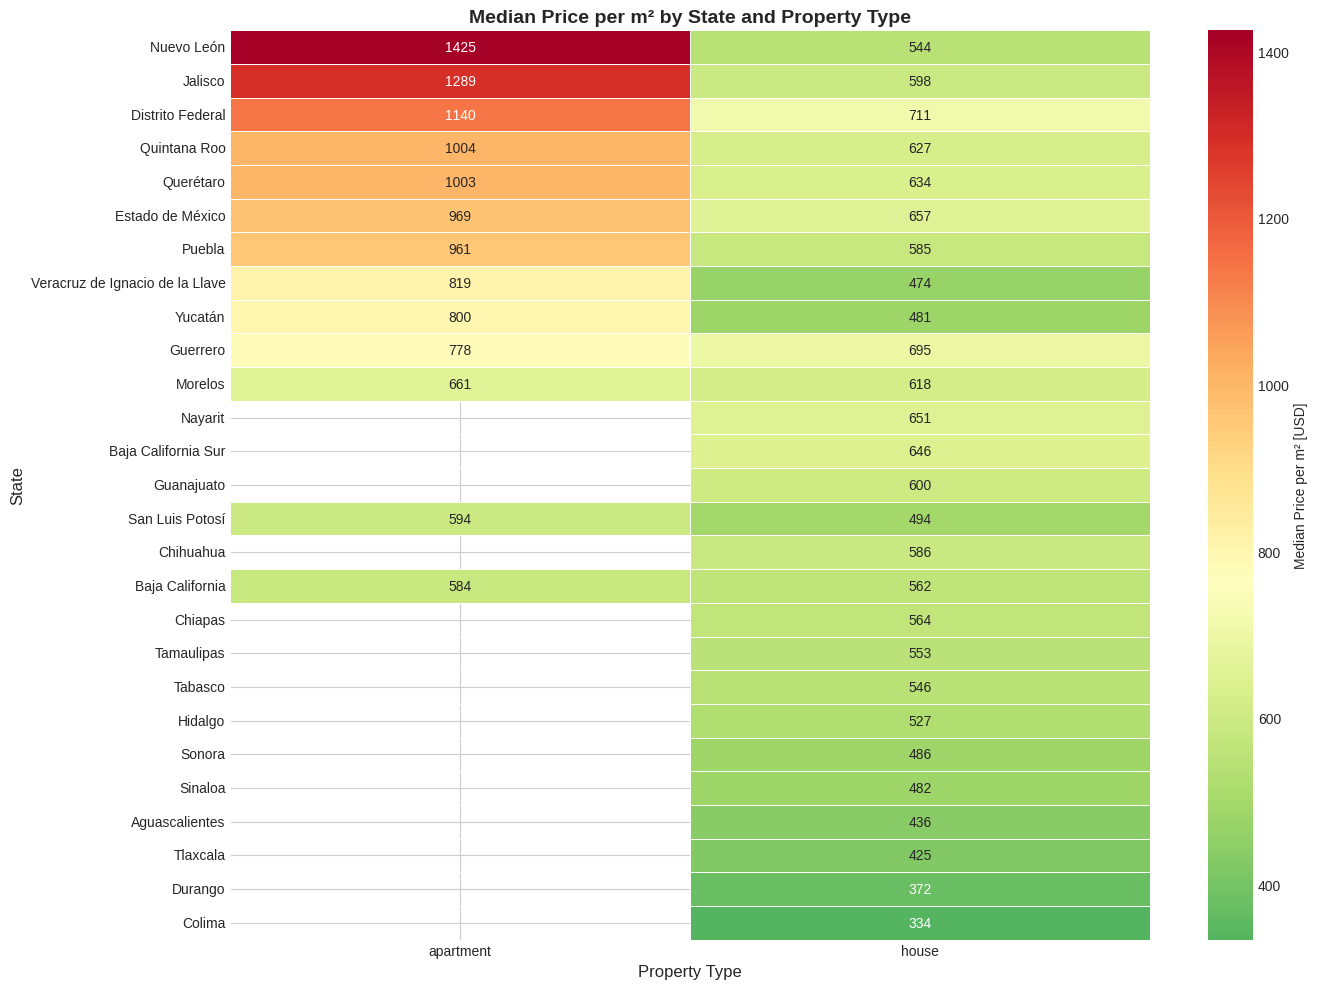

In [69]:
# ============================================
# 6.2 Heatmap of State × Property Type
# ============================================
pivot_median = combined_stats['median'].unstack(level='property_type')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot_median,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    center=pivot_median.median().median(),
    cbar_kws={'label': 'Median Price per m² [USD]'},
    linewidths=0.5,
    linecolor='white'
)
ax.set_title('Median Price per m² by State and Property Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Property Type', fontsize=12)
ax.set_ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()

#7. Diminishing Returns Analysis

=== DIMINISHING RETURNS ANALYSIS ===
Correlation between area and price per m²: -0.2760
 Confirms diminishing returns - larger properties have lower price per m²


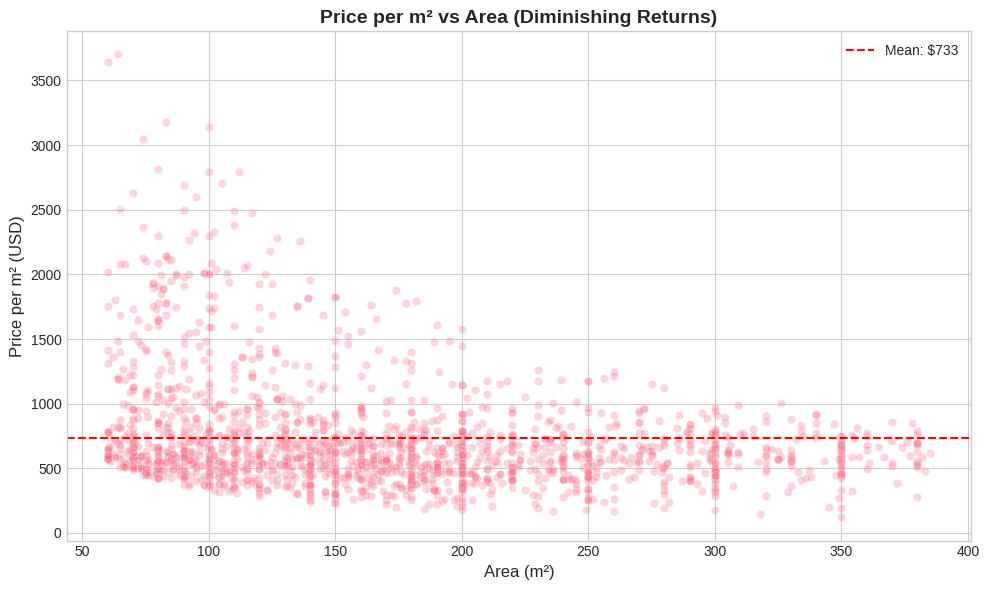

In [70]:
# ============================================
# 7.1 Price per m² vs Area
# ============================================
corr_size_price_per_m2 = df['area_m2'].corr(df['price_per_m2'])
print("=== DIMINISHING RETURNS ANALYSIS ===")
print(f"Correlation between area and price per m²: {corr_size_price_per_m2:.4f}")

if corr_size_price_per_m2 < 0:
    print(" Confirms diminishing returns - larger properties have lower price per m²")
else:
    print(" Positive correlation - check your data")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='area_m2',
    y='price_per_m2',
    alpha=0.3,
    ax=ax
)
ax.set_title('Price per m² vs Area (Diminishing Returns)', fontsize=14, fontweight='bold')
ax.set_xlabel('Area (m²)', fontsize=12)
ax.set_ylabel('Price per m² (USD)', fontsize=12)
ax.axhline(y=df['price_per_m2'].mean(), color='red', linestyle='--',
           label=f'Mean: ${df["price_per_m2"].mean():,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

#8. Summary and Conclusions

In [71]:
# ============================================
# 8.1 Final Summary
# ============================================
print("=" * 60)
print(" MEXICAN REAL ESTATE MARKET ANALYSIS - SUMMARY")
print("=" * 60)

print("\n RESEARCH QUESTION:")
print("Is size (area_m2) a stronger predictor of price than location (state)?")

print("\n KEY FINDINGS:")
print(f"1. Correlation between area and price: {corr_price_area:.3f}")
print(f"2. R-squared: {corr_price_area**2:.3f} ({corr_price_area**2*100:.1f}% of price explained by area)")
print(f"3. Between-state variance: {between_pct:.1f}%")
print(f"4. Within-state variance: {within_pct:.1f}%")
print(f"5. Diminishing returns (area vs price/m²): {corr_size_price_per_m2:.3f}")

print("\n CONCLUSION:")
print("Location (state) explains more price variation than size (area).")
print(f"Location: {between_pct:.1f}% vs Size: {corr_price_area**2*100:.1f}%")
print("\n Location matters more than size in the Mexican real estate market!")

print("\n RECOMMENDATIONS:")
print("1. Focus on location when evaluating property investments")
print("2. Consider diminishing returns - larger properties offer better value per m²")
print("3. Analyze markets at state level for accurate pricing")
print("4. Property type significantly affects price per m²")

 MEXICAN REAL ESTATE MARKET ANALYSIS - SUMMARY

 RESEARCH QUESTION:
Is size (area_m2) a stronger predictor of price than location (state)?

 KEY FINDINGS:
1. Correlation between area and price: 0.586
2. R-squared: 0.343 (34.3% of price explained by area)
3. Between-state variance: 11.8%
4. Within-state variance: 78.3%
5. Diminishing returns (area vs price/m²): -0.276

 CONCLUSION:
Location (state) explains more price variation than size (area).
Location: 11.8% vs Size: 34.3%

 Location matters more than size in the Mexican real estate market!

 RECOMMENDATIONS:
1. Focus on location when evaluating property investments
2. Consider diminishing returns - larger properties offer better value per m²
3. Analyze markets at state level for accurate pricing
4. Property type significantly affects price per m²


#9. Export Results

In [72]:
# ============================================
# 9.1 Save Results to CSV
# ============================================
import os

# Create the results directory if it doesn't exist
results_dir = './results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    print(f"Created directory: {results_dir}")

# Save state statistics
state_price_stats.to_csv(f'{results_dir}/state_price_stats.csv')

# Save property type statistics
property_type_stats.to_csv(f'{results_dir}/property_type_stats.csv')

# Save combined statistics
combined_stats.to_csv(f'{results_dir}/combined_stats.csv')

print("Results saved to CSV files!")

# Save correlation matrix
corr_matrix.to_csv(f'{results_dir}/correlation_matrix.csv')
print("Correlation matrix saved!")

Results saved to CSV files!
Correlation matrix saved!


#10. Requirements and Dependencies

In [73]:
# ============================================
# 10.1 Check Package Versions
# ============================================
import sys

print("=== PACKAGE VERSIONS ===")
print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

=== PACKAGE VERSIONS ===
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
